In [3]:
import pandas as pd

from geoai.utils_ds.visualize_ops import VisualizeOperations
from geoai.utils_ds.dataframe_ops import DataFrameOperations

viz_ops = VisualizeOperations()
dataframe_ops = DataFrameOperations()

In [4]:
# Load the dataset
dataset = pd.read_csv("csv_files/dataset.csv")
dataset

,BLUE,GREEN,RED,NIR,SWIR,Landcover
0,835.33330,920.7500,1301.0000,1478.6666,1976.7500,builtup
1,938.66670,966.3333,1153.0000,1376.0000,2025.2000,builtup
2,871.00000,902.0000,946.0000,1218.0000,2025.2000,builtup
3,985.00000,1050.0000,1114.6666,1573.0000,1974.7500,builtup
4,940.25000,994.5000,1046.0000,1256.5000,1976.7500,builtup
...,...,...,...,...,...,...
2414,390.00000,555.0000,380.0000,3016.6667,1991.0000,trees
2415,366.50000,547.5000,377.0000,3153.3333,2028.3334,trees
2416,365.00000,577.5000,388.0000,3338.0000,2040.5000,trees
2417,377.50000,574.8333,387.5000,3078.6667,1949.6666,trees


# VISUALIZE DATASETS

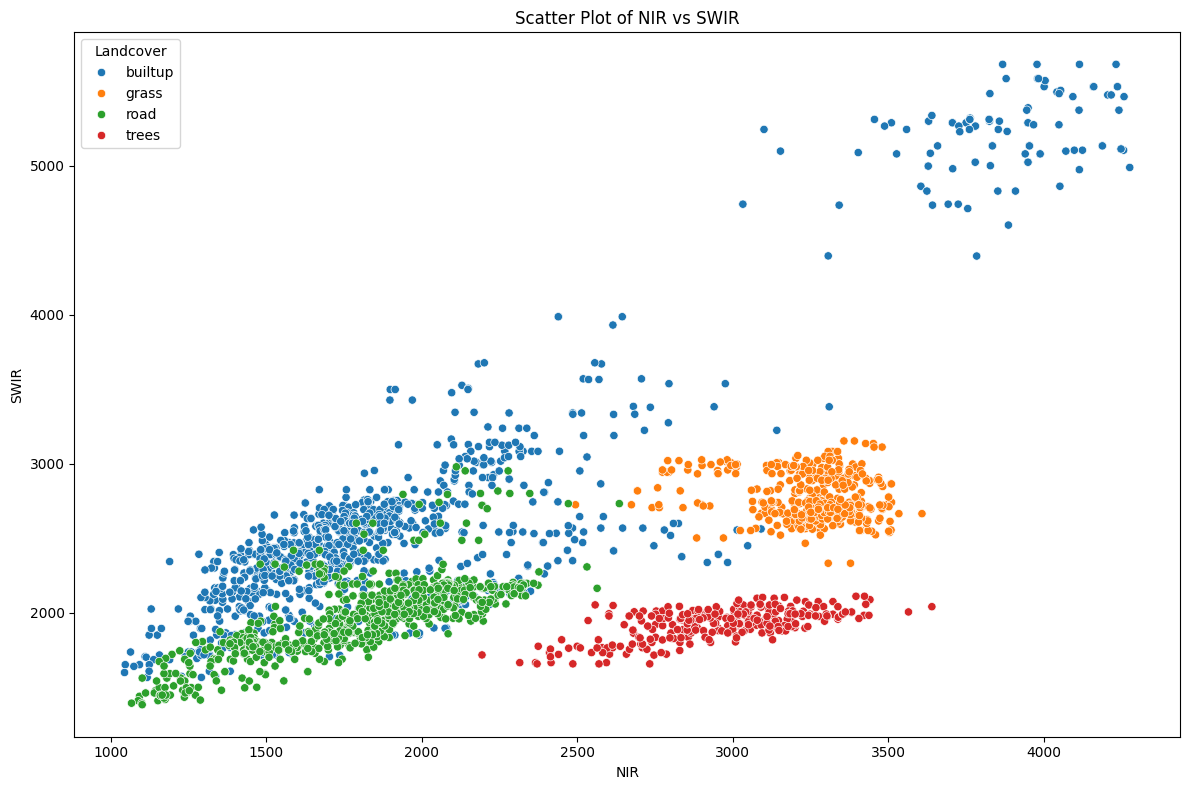

In [5]:
viz_ops.plot_dual_scatter(dataset, "NIR", "SWIR", "Landcover")

- **Insights**:
  - **Builtup areas** Highest NIR values, broadly dispersed in SWIR. Indicates diverse material properties.
  - **Grass** Moderate reflectance, tight cluster in mid to lower NIR and SWIR
    ranges. Uniform reflectance properties typical of vegetation.
  - **Roads** Low reflectance in both NIR and SWIR. Form a distinct, dense cluster indicating consistent reflectance properties typical of road surfaces.
  - **Trees** High reflectance in NIR, low in SWIR. Indicates high water content.

<Figure size 1200x800 with 0 Axes>

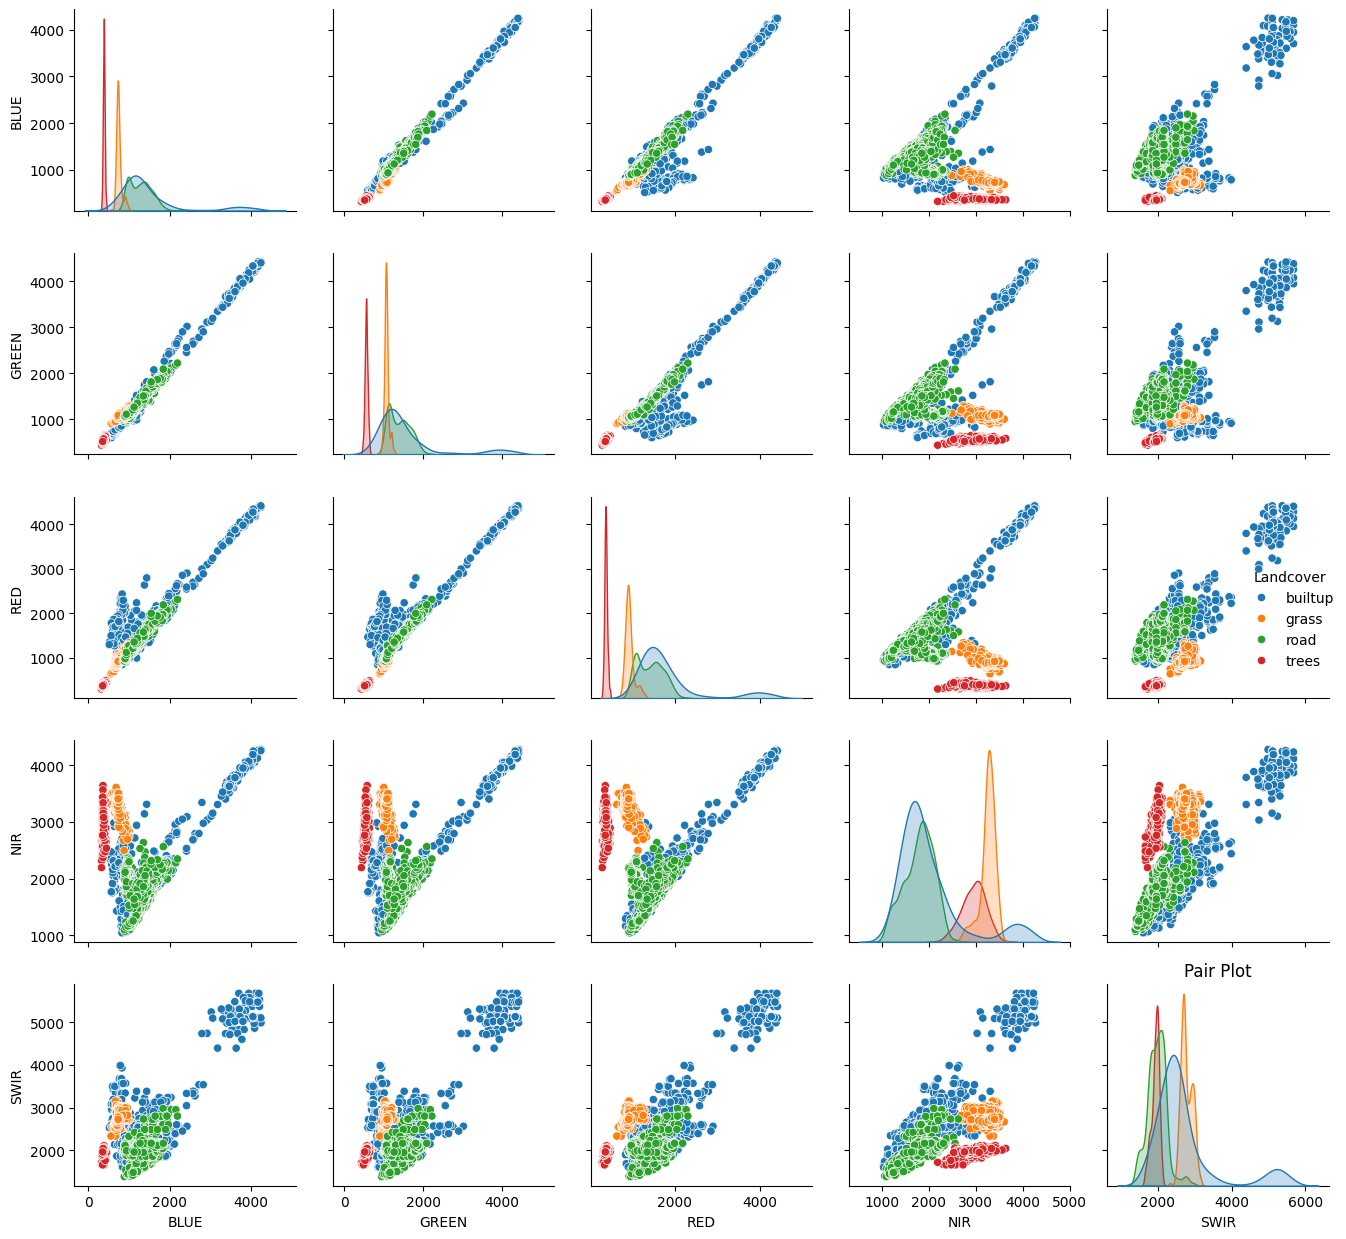

In [6]:
viz_ops.make_pairplot(dataset, "Landcover")

**Class Sepration between RED and NIR**: 
  - **Grass and Trees** have separate clusters in RED and NIR bands and separates well with builtup and roads.
  - **Roads and Builtup areas** have separate clusters with trees and grass but overlap with each other.

<Figure size 1200x800 with 0 Axes>

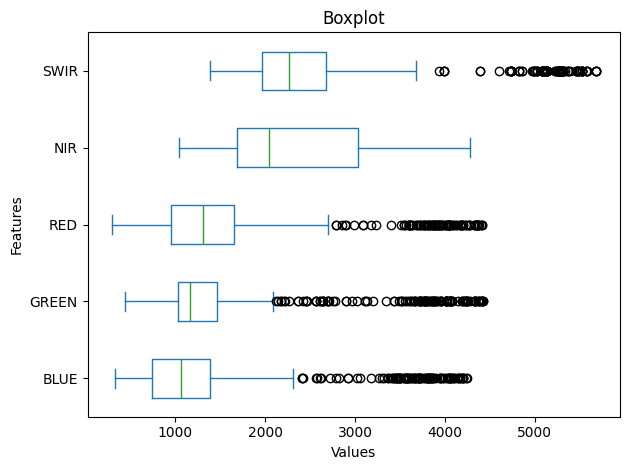

In [7]:
viz_ops.make_box_plot(dataset, "Boxplot")

**SWIR and NIR Values Are More Consistent:**

- **The SWIR and NIR bands have a more balanced spread of values**: This indicates that these features are more consistent

- **RED, GREEN, and BLUE Have Many Outliers**: The RED, GREEN, and BLUE bands show a
  significant number of outliers. This means there are many data points in these
  features that are significantly different from the rest.
- **Greater Spread in NIR Values**: The NIR feature has the widest range of values, indicating more variability. This could suggest that the NIR band captures a diverse set of information.

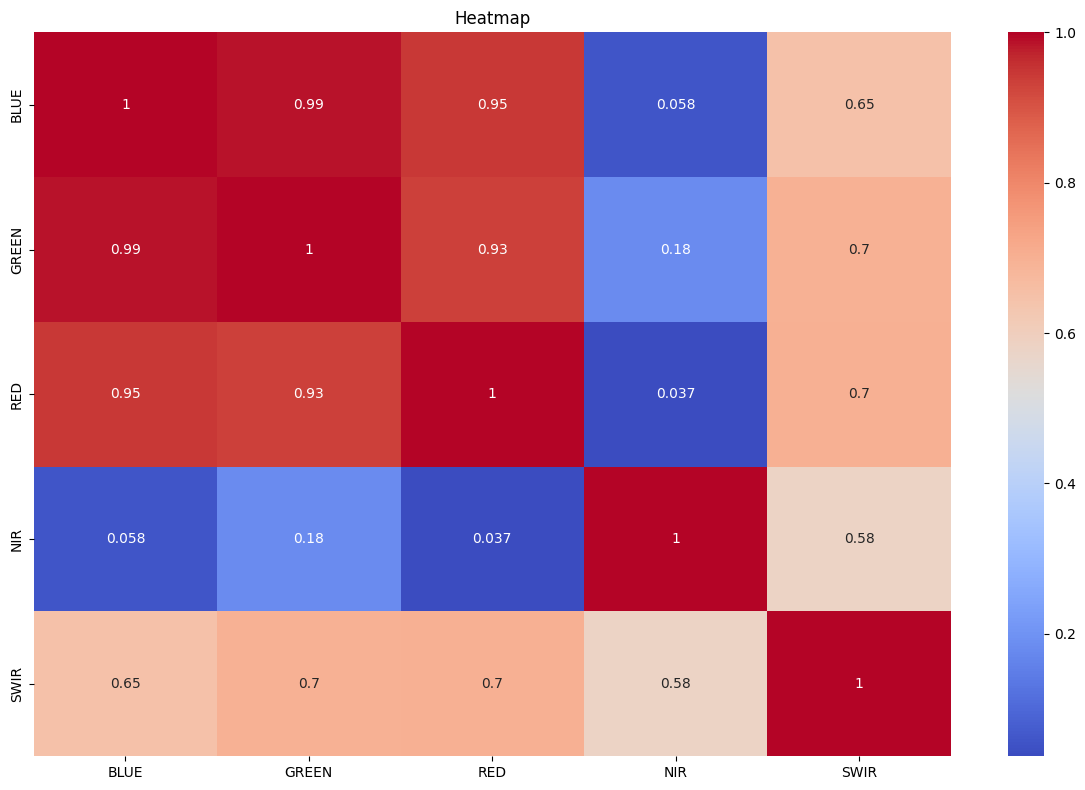

In [8]:
viz_ops.make_heatmap(dataset, "Heatmap")

**Visual Interpretation**:

- Red Cells: Indicate a high positive correlation (e.g., BLUE and GREEN).
- Blue Cells: Indicate a low or no correlation (e.g., NIR and RED).
- Light Colored Cells: Indicate moderate correlation (e.g., SWIR and GREEN).

**Strong Correlation Among BLUE, GREEN, and RED**:

The BLUE, GREEN, and RED bands have very high correlation values with each other
(close to 1). Suggesting these bands capture similar information in the data.

**Weak Correlation Between NIR and Other Bands**:

The NIR (Near-Infrared) band has very low correlation values with BLUE, GREEN, and RED bands. This indicates that NIR captures different information compared to the visible spectrum (BLUE, GREEN, and RED).

**Moderate Correlation of SWIR with Other Bands**:

The SWIR (Shortwave Infrared) band has moderate correlation values with the other bands, especially GREEN and RED. This suggests that SWIR is somewhat related to these bands but also captures unique information.

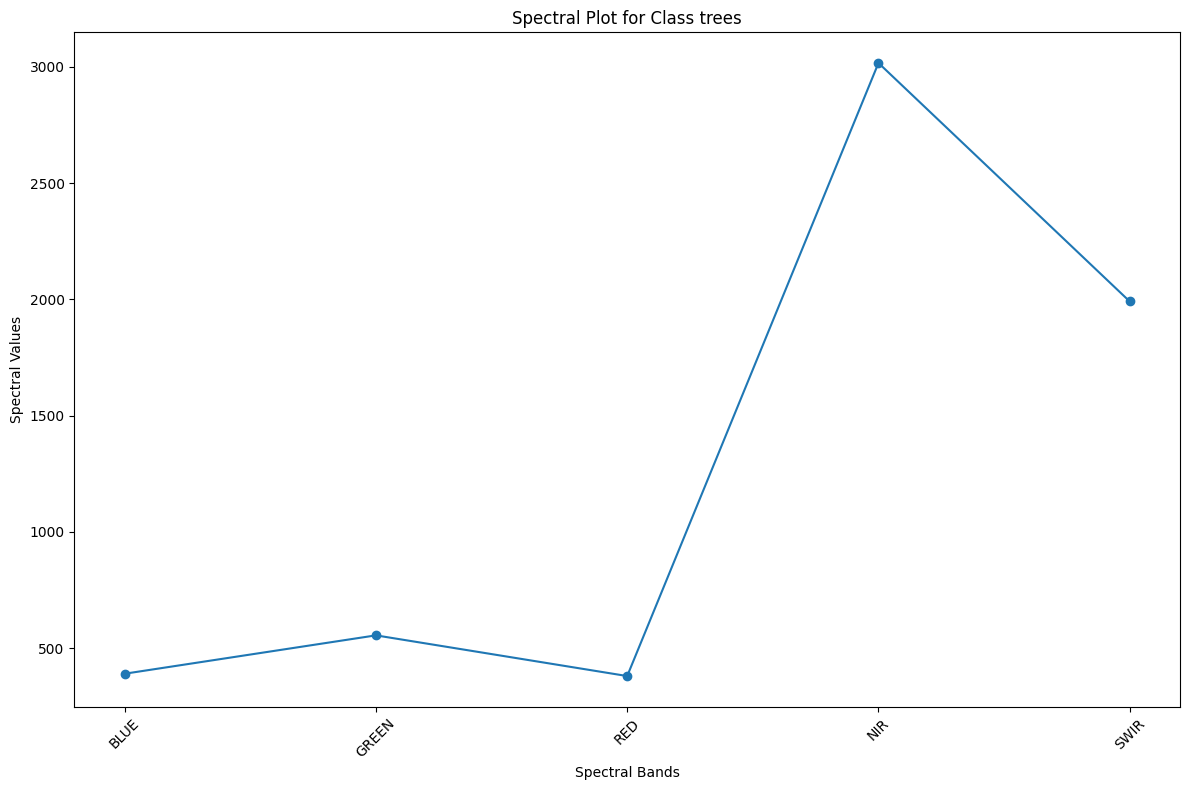

In [9]:
viz_ops.plot_row(dataset.iloc[2414, :-1], "trees")

**Key Insights**:

- **Low Values in Visible Bands**:

The BLUE, GREEN, and RED bands have relatively low values compared to the other bands. This indicates that the tree class reflects less light in the visible spectrum.

- **High NIR Values**:

The NIR (Near-Infrared) band shows a very high value. This is typical for
healthy vegetation, as plants reflect a lot of near-infrared light.

- **Moderate SWIR Values**:

The SWIR (Shortwave Infrared) band has a value higher than the visible bands but lower than the NIR. SWIR can provide additional information about the water content and structure of the vegetation.

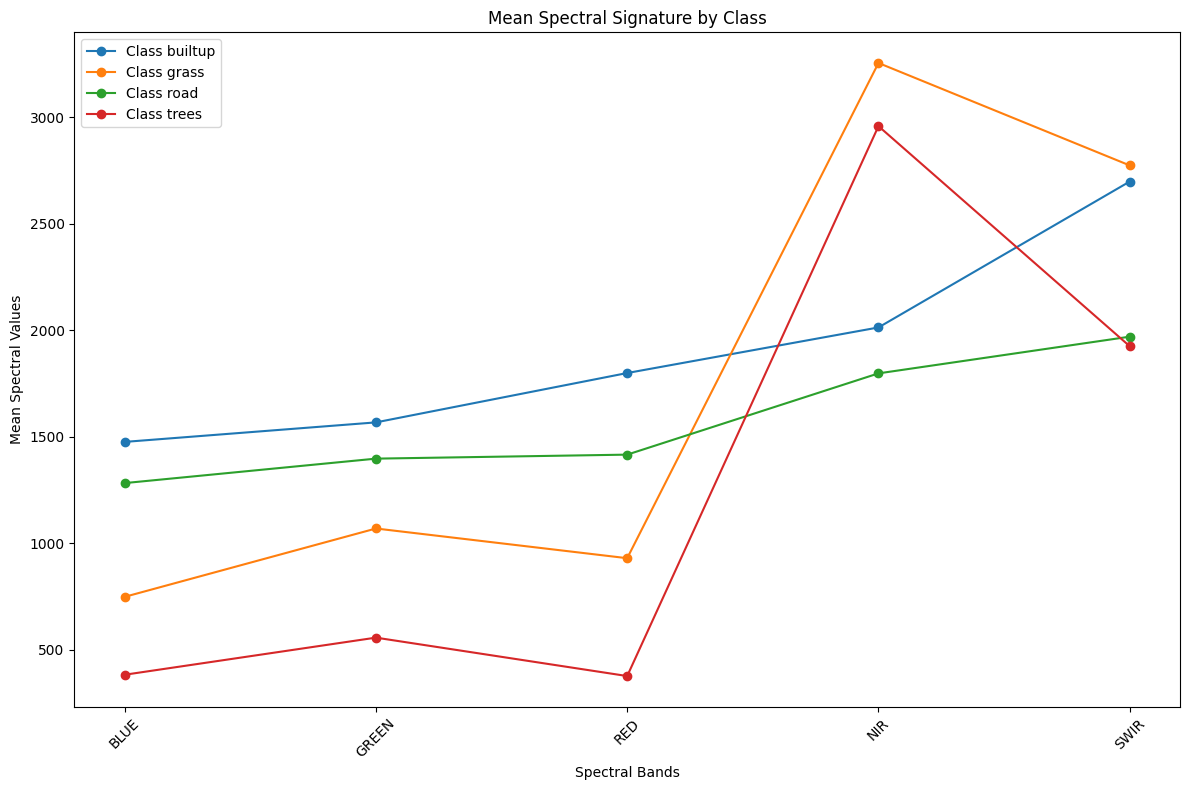

In [10]:
viz_ops.plot_spectral(dataset, "Landcover")

**Class Built-Up**:

The spectral values for built-up areas are relatively high across all bands, showing a gradual increase from BLUE to SWIR. This indicates that built-up areas reflect more light consistently across different wavelengths.

**Class Grass**:

Grass has lower values in the visible bands (BLUE, GREEN, RED) but peaks sharply in the NIR band. This high NIR reflectance is typical for vegetation.

**Class Road**:

Roads have moderate values across all bands, with a gradual increase but no sharp peaks. This indicates a relatively even reflection across different wavelengths, differentiating them from vegetation.

**Class Trees**:

Trees have low values in the visible bands and a sharp increase in the NIR band, similar to grass. However, their values are slightly lower than grass in the NIR band, and they show a moderate value in the SWIR band.

In [11]:
viz_ops.generate_profile_report(dataset, "PROFILE")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Remove duplicates

In [12]:
dataset = dataframe_ops.remove_duplicate_rows(dataset)
dataset.to_csv("csv_files/dataset_no_duplicates.csv", index=False)

END